# Homework 2
## Анализ текста, текстовые модели



### Часть 1: Анализ текста с помощью TF-IDF

Цель:

Изучить метод TF-IDF для векторизации текста
Сравнить различные подходы к векторизации
Провести статистический анализ текстовых данных

#### **Задание для части 1:**

1. Рассчитайте метрику TF-IDF для любых трех песен на выбранном вами языке. (30%)

2. Сравните TF-IDF с другими методами векторизации текста, такими как Count Vectorizer, Word2Vec или Doc2Vec. (30%)

3. Проведите исследование, используя полученные преобразованные данные; какие слова/фразы встречаются чаще всего, а какие реже. (20%)

In [120]:
# !pip install gensim

In [121]:
songs = [
    """
Сид Вишес умер у тебя на глазах!
Джон Леннон умер у тебя на глазах!
Джим Моррисон умер у тебя на глазах!
А ты остался таким же как был…

Всего два выхода для честных ребят:
Схватить автомат и убивать всех подряд!
Или покончить с собой, с собой, с собой, с собой, с собой, с собой!
Если всерьёз воспринимать этот мир…

Цель оправдывает средства — давай!
Убивай, насилуй, клевещи, предавай!
Ради светлого, светлого, светлого, светлого
Светлого здания идей чучхе!

Всё то, что не доделал Мамай!
Октябрь доделал, довёл до конца!
Октябрь довёл до последней черты!
И всем нам нечего делать здесь…

Мой друг повесился у вас на глазах!
Он сделал харакири у вас на крыльце!
Он истёк надеждой и всем, чем мог!
А все вы остались такими же…

А все вы остались такими же…
    """,
    """
Хотите со мной сфоткаться?
Я фанерная фигура у автомойки
Закрываются ворота
Бригадиры, рабочие уходят
Я остаюсь один
Проспект теряется в ночи
Всё это сон или я приговорен
Здесь стыть, пока не вышел мой срок?
Если нужен автограф
Я оборванная доска объявлений
У ждущей сноса хрущёвки
Где гортензии на старой мебели?
Меня обнять не сможете
Я — ночь с тихими стонами и пальцами, как копья
Что ищет сердце под футболкой
Размокшей после рейва
Разводы портвейна
На стенках кружки, подаренной в честь юбилея
Я — рельсы, по которым шарит усталый шкуроход
Рукой не находя чужой закладки
Всё окутано стылой тоской
Холодное утро
Я — гневный плакат под летним дождём
Своим стилусом ОМОН лицо автора перечеркнёт
Счётчик задержаний снова напомнит, кто здесь лёд
Но на нём никто не подскользнётся, никто не упадёт
Вы не уместитесь со мной на кровати в приёмном покое
Железная сетка свисает до пола
Одинокому — горе
А делить себя с кем-то уже не позволяет здоровье
Только кошмары приходят, и мы сочиняем истории
Скорей бы ёбнуться от бессонницы или пустить кровь, но
Есть только матрас и молчаливые книжные полки
Я — просто вопль без пола, возраста, лица и формы
Вы меня не услышите, даже если засунете в уши колонки

Твоё равнодушие — моя смирительная рубашка
А под кожу, а под кожу мне запускают дельфинов стаю
И я вроде их слушаю (и улетаю)
Но мне уже не важно
Туда, где всё не так уж важно
Всё не так уж плохо

Жить — значит правильно делать выбор: дурка или бордель
Переключаю рычаг на тщеславие, уныние и похоть преодолев
Твой образ держу в голове, как фигу в кармане, тайком от врачей
Выстраиваю новый дом вместо старого, который сгорел
Знаю, что ты отменишь все мои песни одним щелчком
Для тебя я и наше прошлое — просто симптом
Шагами в больничной палате измеряют длину разлуки
На наши общие мечты, как с другой планеты смотрю
Открываю каждую новую дверь, как портал в другой мир
Ищу точку опоры, обучаюсь по новой сходиться с людьми
Усилием воли не даю себе увидеть чудовищ вместо всех них
Из забытых снов просыпайся и создавай себе единые огни
Дозировка оланзапина и вальдоксана, на ночь аминазин
Помогают поверить, что каждый человек заменим
Новый день даст по печени и за спиной заломит руки, как мент
Убивая мозг, кроша прошлое на бессмысленные фрагменты
В этой комнате никогда не было нас — это был сон
Увиденный в маниакальной стадии. Мы снова с тобой не знакомы
Мы никогда не гуляли на этих улицах — это был бред
Скоро он потеряет свои очертания, как воспоминания детства
Пока вытираю посуду, выхожу в город ночных кошмаров
Вдыхая холодный воздух и видения воспалённого мозга сжигая
Измельчаю таблетки шагами вечернего променада
Тебя нет. Есть только расстояние между двух стен палаты

Твоё равнодушие — моя смирительная рубашка
А под кожу, а под кожу мне запускают дельфинов стаю
И я вроде их слушаю (и улетаю)
Но мне уже не важно
Туда, где всё не так уж важно
Всё не так уж плохо
    """,
    """
В эти сугробы я зарываю свои письма тебе
По выходным они распускаются ночью
Чьей-то кровью, зубами и пивом, как подснежники
Танцующие уродцы в арке на электрозаводе
На этих улицах нельзя заблудиться, как хочется
Везде натыкаешься на новый крафтовый паб
Отсутствие тебя выходит за рамки своих полномочий
Как глава одной республики, финансируемой милостью Аллаха
Тебя нет во всём мире, и на каждом конкретном шагу
Под треск рвущихся на панк-концертах свитшотов
Я рисую себе мост из наших сплетённых рук
Его было бы видно из любой точки города
Я рассмотрел все лица в вагоне - это не ты
Но всё равно представляю себя тяжёлым, толстым парнем
Любителем хинкалей, у него дома в горшках цветы
На подоконнике, "спрячься за мной в случае терракта"
Книги - как корнеплоды на рынке, без всяких примет
Ни одна из них не сократит расстояние между сном и реальностью
Между твоей и моей постелью
И буквы толкаются, как на вокзале
Испуганные пассажиры, покидающие город-призрак
Каждый сам за себя, и я смотрю на них сквозь улыбку
Мне некуда бежать, и в принципе я согласился бы на ножевое
Пока мои губы всё ещё пахнут тобой

Бросаюсь как под поезд под ноги в этом городе
Я пёс, и мне надо найти хотя бы один твой волос
Как на бомбу и наркотики, натаскан на образ
За которым спускаюсь на дно и выбираюсь на солнце
Бросаюсь как под поезд под ноги в этом городе
Я пёс, и мне надо найти хотя бы один твой волос
Как на бомбу и наркотики, натаскан на образ
За которым спускаюсь на дно и выбираюсь на солнце

Снег тает, и запахи начинают сбивать меня с толку
Под вечер автомобили, как животные в лесу, просыпаются
Внимательно наблюдаю, пока жду тебя у парковки
Каждый день в мегаполисе поиск того, что нельзя описать
Смотрю в эти лица, и на каждом его отпечаток
Как в лужах город оставил своё искажённое отражение
Внушает страх, дарит надежду и тут же её отнимает
Жизнь измеряется покупками и коммунальными платежами
Люди бегут из этого леса в свои ветхие хижины
Места наших встреч станут моей городской картой
Скалятся гнилыми зубами, отвергнутые и униженные
Не успевшие схватить жертву, обменники и ломбарды
Медленно продвигаюсь к тебе, смывая как грязь своё прошлое
Паутину временных местожительств и всех этих столовок
Я сотню раз был застигнут повседневной пошлостью
Но моя история до тебя просто была тренировкой
Как в этой враждебной среде не растерять твой запах?
Набранные в кредит товары разрывают их сумки
Мне тоже нужно набрать всё необходимое наспех
Но пока мои пальцы пахнут тобой, я не растворюсь в этой скуке
Начало твоего дня станет моим дедлайном
Я прошёл эти маршруты, предвкушая что-то неосязаемое
Подставляю морду лучам твоего пробуждения, ожидая
Мои стихи как добыча, которую пёс приносит хозяину

Бросаюсь как под поезд под ноги этому городу
Я пёс, достаточно надежды на взгляд и команды
Сторожить твои книги, забытые в проходной комнате
Просто прожить этот день или в глотку вцепиться зубами
Бросаюсь как под поезд под ноги этому городу
Я пёс, достаточно надежды на взгляд и команды
Сторожить твои книги, забытые в проходной комнате
Просто прожить этот день или в глотку вцепиться зубами
    """
]

song_names = ["Гражданская оборона – Харакири",
              "макулатура - променад",
              "макулатура - ножевое"]



In [ ]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize
from gensim.models import Word2Vec

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from wordcloud import WordCloud

from collections import Counter
import re
import time


In [123]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [124]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


In [125]:
class what:
  class time:
    @staticmethod
    def is_(func):
      def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        tt = end - start
        print(f'{func.__name__} took {tt:.4f} seconds')
        return result, tt
      return wrapper


In [126]:
def preprocess_songs(songs, song_names):
    def clean_text(text):
        text = text.lower()
        text = re.sub(r'[^а-яa-z\s]', '', text)
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('russian') + stopwords.words('english'))
        tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
        return ' '.join(tokens)

    return [clean_text(song) for song in songs]


In [127]:
@what.time.is_
def count_vec(txt):
  c_v = CountVectorizer()
  return c_v.fit_transform(txt), c_v.get_feature_names_out()


@what.time.is_
def tfidf(txt):
  tf = TfidfVectorizer(use_idf=True)
  return tf.fit_transform(txt), tf.get_feature_names_out()


@what.time.is_
def w2v(txt):
  sts = [tt.split() for tt in txt]
  return Word2Vec(sts,
                  vector_size=70,
                  window=5,
                  min_count=1,
                  workers=4)


In [128]:
prepared_songs = preprocess_songs(songs, song_names)


In [129]:
(count_vectorizer_matrix, feature_names), cv_time = count_vec(prepared_songs)


count_vec took 0.0033 seconds


In [130]:
(tf_idf_matrix, feature_names_tfidf), tf_time = tfidf(prepared_songs)


tfidf took 0.0044 seconds


In [131]:
word2vec_model, w2v_time = w2v(prepared_songs)


w2v took 0.0290 seconds


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def plot_execution_times(cv_time, tf_time, w2v_time, save_path=None):
    methods = ['CountVectorizer', 'TF-IDF', 'Word2Vec']
    times = [cv_time, tf_time, w2v_time]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    bars = ax1.bar(methods, times, color=colors, alpha=0.8)
    ax1.set_ylabel('Время выполнения (секунды)', fontsize=12)
    ax1.set_title('Сравнение времени выполнения методов', fontsize=14, fontweight='bold')

    for bar, time in zip(bars, times):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.4f} с', ha='center', va='bottom', fontsize=10)

    wedges, texts, autotexts = ax2.pie(times, labels=methods, autopct='%1.1f%%',
                                       colors=colors, startangle=90)
    ax2.set_title('Распределение времени выполнения', fontsize=14, fontweight='bold')

    plt.suptitle('Анализ производительности методов', fontsize=16, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return pd.DataFrame({
        'Метод': methods,
        'Время_сек': times,
        'Доля_%': [t/sum(times)*100 for t in times]
    })


def plot_word_frequencies(count_matrix, feature_names, song_names, top_n=20, save_path=None):
    total_freq = np.array(count_matrix.sum(axis=0)).flatten()

    top_indices = total_freq.argsort()[-top_n:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_frequencies = [total_freq[i] for i in top_indices]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Анализ частотности слов', fontsize=16, fontweight='bold', y=1.02)

    ax1 = axes[0, 0]
    bars = ax1.barh(range(len(top_words)), top_frequencies, color='coral')
    ax1.set_yticks(range(len(top_words)))
    ax1.set_yticklabels(top_words)
    ax1.set_xlabel('Частота')
    ax1.set_title(f'Топ-{top_n} самых частотных слов (все песни)', fontsize=12)
    ax1.invert_yaxis() 

    for i, (bar, freq) in enumerate(zip(bars, top_frequencies)):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{int(freq)}', va='center', fontsize=9)

    ax2 = axes[0, 1]
    
    top15_indices = total_freq.argsort()[-15:][::-1]
    top15_words = [feature_names[i] for i in top15_indices]

    heatmap_data = []
    for i in range(len(song_names)):
        song_freq = count_matrix[i].toarray()[0][top15_indices]
        heatmap_data.append(song_freq)

    sns.heatmap(heatmap_data,
                xticklabels=top15_words,
                yticklabels=song_names,
                annot=True,
                fmt='d',
                cmap='YlOrRd',
                ax=ax2,
                cbar_kws={'label': 'Частота'})
    ax2.set_title('Распределение частот по песням', fontsize=12)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

    ax3 = axes[1, 0]
    freqs_nonzero = total_freq[total_freq > 0]
    ax3.hist(freqs_nonzero, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Частота слова')
    ax3.set_ylabel('Количество слов')
    ax3.set_title('Распределение частот слов', fontsize=12)
    ax3.set_yscale('log')
    ax3.axvline(np.mean(freqs_nonzero), color='red', linestyle='--', label=f'Среднее: {np.mean(freqs_nonzero):.1f}')
    ax3.legend()

    ax4 = axes[1, 1]
    sorted_freqs = np.sort(total_freq)[::-1]
    cumulative = np.cumsum(sorted_freqs) / np.sum(sorted_freqs) * 100

    ax4.plot(range(1, len(cumulative)+1), cumulative, 'b-', linewidth=2)
    ax4.set_xlabel('Количество уникальных слов')
    ax4.set_ylabel('Накопленная частотность (%)')
    ax4.set_title('Кривая накопления частот', fontsize=12)
    ax4.grid(True, alpha=0.3)

    idx_80 = np.argmax(cumulative >= 80)
    ax4.axhline(y=80, color='red', linestyle='--', alpha=0.5)
    ax4.axvline(x=idx_80, color='red', linestyle='--', alpha=0.5)
    ax4.text(idx_80+5, 50, f'80% частот покрывают\n{idx_80} слов', fontsize=9)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


    return pd.DataFrame({
        'Слово': top_words,
        'Частота': top_frequencies,
        'Доля_%': [f/sum(total_freq)*100 for f in top_frequencies]
    })

def plot_matrix_heatmaps(count_matrix, tfidf_matrix, feature_names, song_names,
                         top_n=50, save_path=None):
    total_freq = np.array(count_matrix.sum(axis=0)).flatten()
    top_indices = total_freq.argsort()[-top_n:][::-1]
    top_words = [feature_names[i] for i in top_indices]

    count_subset = count_matrix[:, top_indices].toarray()
    tfidf_subset = tfidf_matrix[:, top_indices].toarray()

    count_norm = normalize(count_subset, norm='l1', axis=1)
    tfidf_norm = tfidf_subset

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Тепловые карты (топ-{top_n} слов)', fontsize=16, fontweight='bold', y=1.02)

    ax1 = axes[0]
    sns.heatmap(count_norm,
                xticklabels=top_words,
                yticklabels=song_names,
                cmap='viridis',
                ax=ax1,
                cbar_kws={'label': 'Нормированная частота'})
    ax1.set_title('CountVectorizer (нормированные частоты)', fontsize=14)
    ax1.set_xlabel('Слова')
    ax1.set_ylabel('Песни')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    ax2 = axes[1]
    sns.heatmap(tfidf_norm,
                xticklabels=top_words,
                yticklabels=song_names,
                cmap='plasma',
                ax=ax2,
                cbar_kws={'label': 'TF-IDF вес'})
    ax2.set_title('TF-IDF', fontsize=14)
    ax2.set_xlabel('Слова')
    ax2.set_ylabel('Песни')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'count_matrix_subset': count_subset,
        'tfidf_matrix_subset': tfidf_subset,
        'top_words': top_words
    }


def plot_wordclouds(count_matrix, feature_names, song_names, save_path=None):
    total_freq = np.array(count_matrix.sum(axis=0)).flatten()
    word_freq_dict = dict(zip(feature_names, total_freq))

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('WordCloud визуализация', fontsize=16, fontweight='bold', y=1.02)

    ax1 = axes[0, 0]
    wordcloud_total = WordCloud(width=400, height=300,
                               background_color='white',
                               colormap='viridis',
                               max_words=50).generate_from_frequencies(word_freq_dict)
    ax1.imshow(wordcloud_total, interpolation='bilinear')
    ax1.set_title('Все песни', fontsize=14)
    ax1.axis('off')


    for idx, (ax, song_name) in enumerate(zip([axes[0, 1], axes[1, 0], axes[1, 1]], song_names)):
        song_freq = count_matrix[idx].toarray()[0]
        song_freq_dict = dict(zip(feature_names, song_freq))

        song_freq_dict = {k: v for k, v in song_freq_dict.items() if v > 0}

        wordcloud = WordCloud(width=400, height=300,
                            background_color='white',
                            colormap='plasma',
                            max_words=30).generate_from_frequencies(song_freq_dict)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(song_name, fontsize=14)
        ax.axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_methods_comparison(count_matrix, tfidf_matrix, feature_names, song_names, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Сравнительный анализ методов векторизации', fontsize=16, fontweight='bold', y=1.02)

    ax1 = axes[0, 0]
    sparsity_count = 1 - (count_matrix.nnz / (count_matrix.shape[0] * count_matrix.shape[1]))
    sparsity_tfidf = 1 - (tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))

    methods = ['CountVectorizer', 'TF-IDF']
    sparsity = [sparsity_count * 100, sparsity_tfidf * 100]
    colors = ['#FF6B6B', '#4ECDC4']

    bars = ax1.bar(methods, sparsity, color=colors)
    ax1.set_ylabel('Разреженность (%)')
    ax1.set_title('Разреженность матриц', fontsize=12)
    for bar, s in zip(bars, sparsity):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{s:.1f}%', ha='center', fontsize=10)

    ax2 = axes[0, 1]
    tfidf_values = tfidf_matrix.data
    ax2.hist(tfidf_values, bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('TF-IDF вес')
    ax2.set_ylabel('Количество')
    ax2.set_title('Распределение TF-IDF весов', fontsize=12)

    ax3 = axes[0, 2]
    total_freq = np.array(count_matrix.sum(axis=0)).flatten()
    top10_freq_idx = total_freq.argsort()[-10:][::-1]
    top10_freq_words = [feature_names[i] for i in top10_freq_idx]
    top10_freq_values = [total_freq[i] for i in top10_freq_idx]

    avg_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
    top10_tfidf_idx = avg_tfidf.argsort()[-10:][::-1]
    top10_tfidf_words = [feature_names[i] for i in top10_tfidf_idx]

    ax3.barh(range(10), top10_freq_values, color='#FF6B6B', alpha=0.7, label='Частота')
    ax3.set_yticks(range(10))
    ax3.set_yticklabels(top10_freq_words)
    ax3.set_xlabel('Частота')
    ax3.set_title('Топ-10 по частоте', fontsize=12)
    ax3.invert_yaxis()

    ax4 = axes[1, 0]
    freq_set = set(top10_freq_words[:5])
    tfidf_set = set(top10_tfidf_words[:5])

    venn2([freq_set, tfidf_set], ('По частоте', 'По TF-IDF'), ax=ax4)
    ax4.set_title('Пересечение топ-5 слов', fontsize=12)

    ax5 = axes[1, 1]
    
    word_presence = np.array((count_matrix > 0).sum(axis=0)).flatten()
    common_words_idx = np.where(word_presence == len(song_names))[0]

    if len(common_words_idx) > 0:
        common_freq = [total_freq[i] for i in common_words_idx]
        common_tfidf = [avg_tfidf[i] for i in common_words_idx]
        ax5.scatter(common_freq, common_tfidf, alpha=0.6, color='purple')
        ax5.set_xlabel('Частота')
        ax5.set_ylabel('Средний TF-IDF')
        ax5.set_title('Частота vs TF-IDF (общие слова)', fontsize=12)

        z = np.polyfit(common_freq, common_tfidf, 1)
        p = np.poly1d(z)
        ax5.plot(sorted(common_freq), p(sorted(common_freq)), "r--", alpha=0.8)

    ax6 = axes[1, 2]
    ax6.axis('off')
    stats_text = f"""
    Статистика корпуса:
    • Песен: {len(song_names)}
    • Уникальных слов: {len(feature_names)}
    • Всего слов: {int(total_freq.sum())}

    CountVectorizer:
    • Ненулевых элементов: {count_matrix.nnz}
    • Средняя частота: {np.mean(total_freq[total_freq>0]):.1f}

    TF-IDF:
    • Средний вес: {np.mean(tfidf_values):.4f}
    • Макс вес: {np.max(tfidf_values):.4f}
    """
    ax6.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()



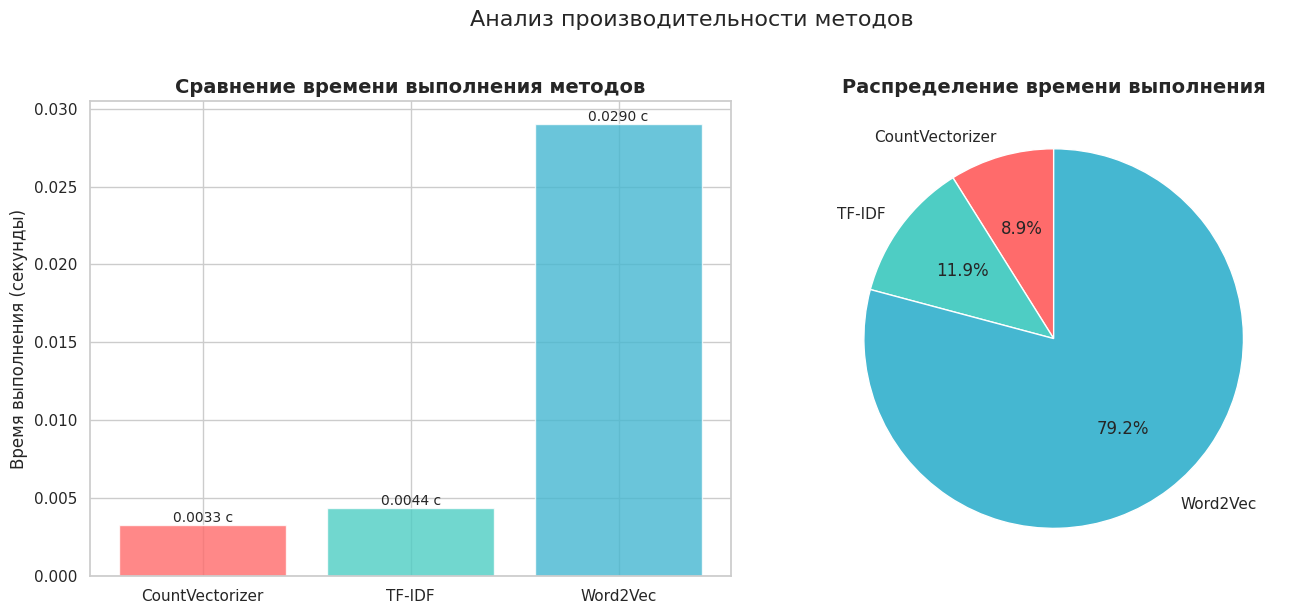

             Метод  Время_сек     Доля_%
0  CountVectorizer   0.003266   8.906211
1           TF-IDF   0.004377  11.935194
2         Word2Vec   0.029029  79.158594


In [135]:
time_df = plot_execution_times(cv_time, tf_time, w2v_time, save_path='times.png')
print(time_df)


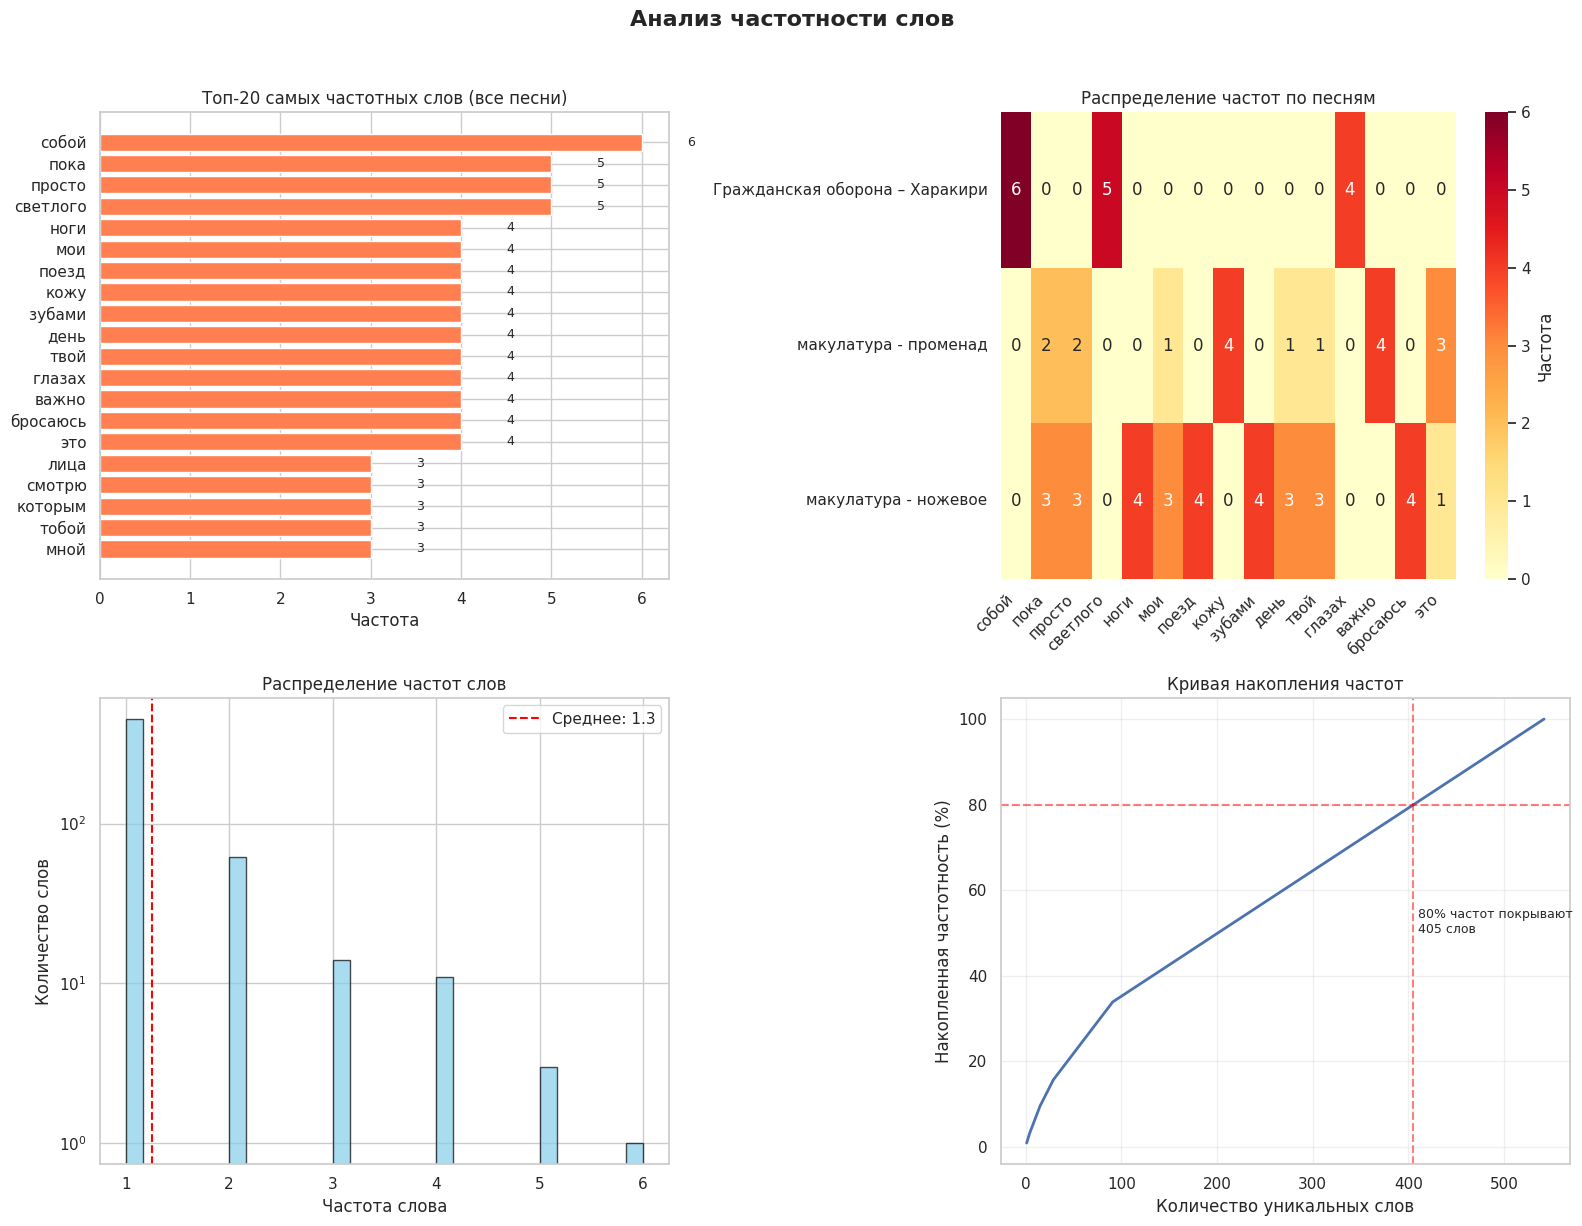

       Слово  Частота    Доля_%
0      собой        6  0.879765
1       пока        5  0.733138
2     просто        5  0.733138
3   светлого        5  0.733138
4       ноги        4  0.586510
5        мои        4  0.586510
6      поезд        4  0.586510
7       кожу        4  0.586510
8     зубами        4  0.586510
9       день        4  0.586510
10      твой        4  0.586510
11    глазах        4  0.586510
12     важно        4  0.586510
13  бросаюсь        4  0.586510
14       это        4  0.586510
15      лица        3  0.439883
16    смотрю        3  0.439883
17   которым        3  0.439883
18     тобой        3  0.439883
19      мной        3  0.439883


In [136]:
freq_df = plot_word_frequencies(count_vectorizer_matrix, feature_names, song_names, top_n=20)
print(freq_df)


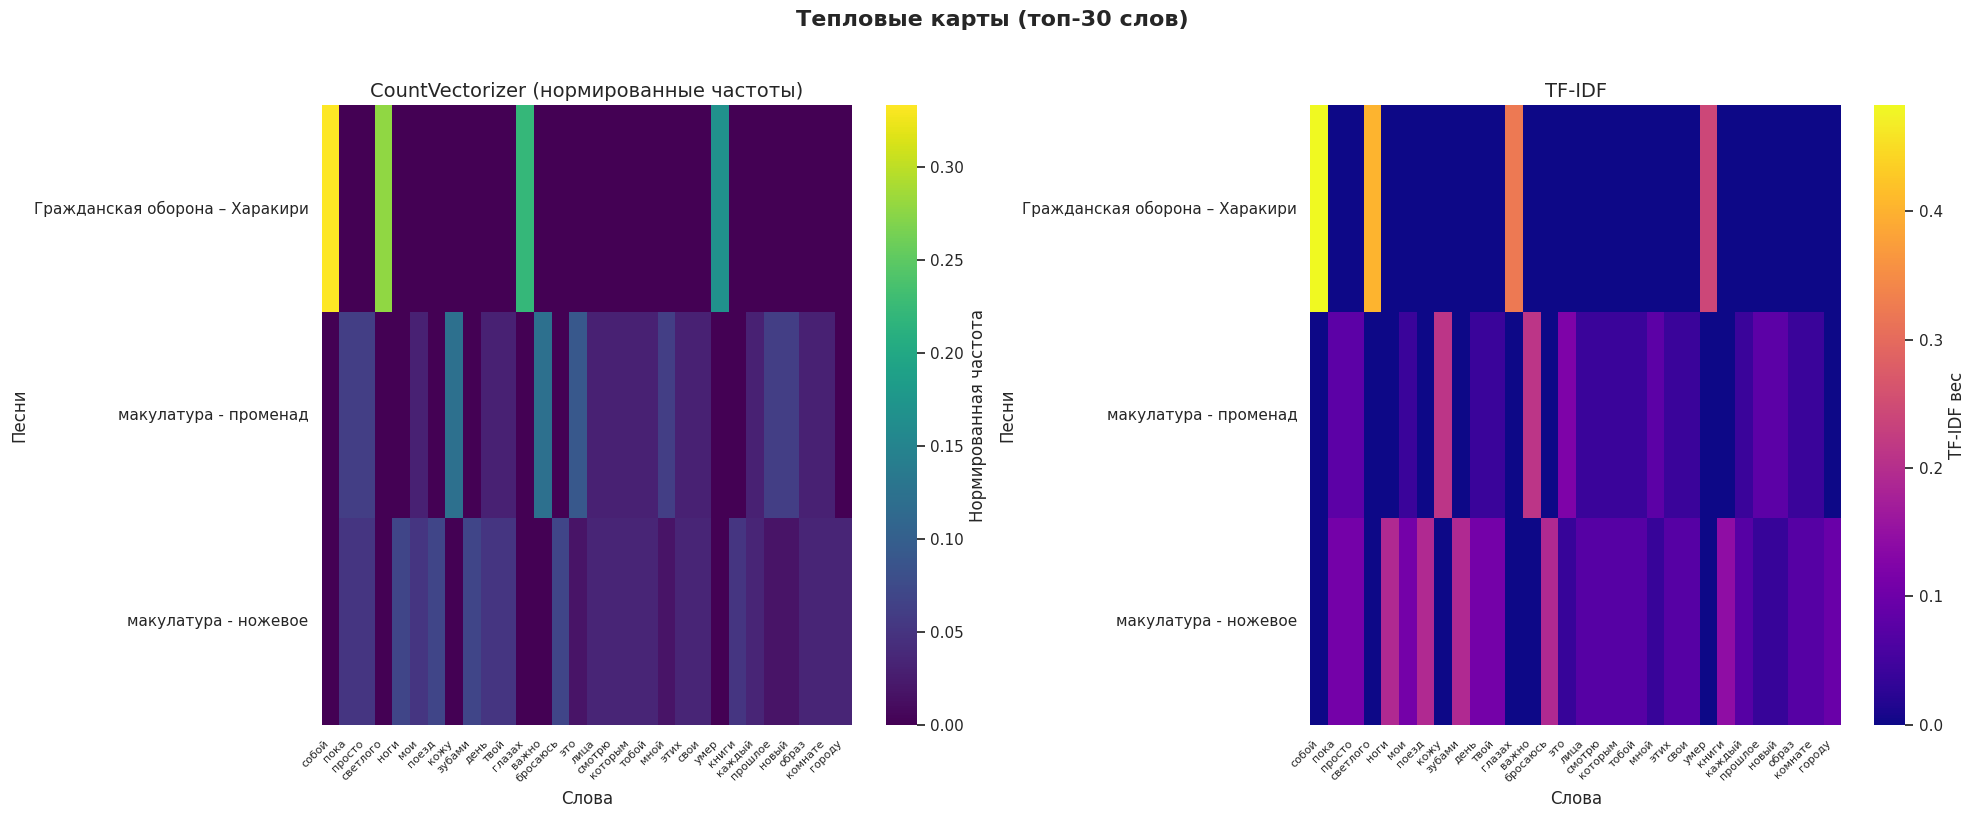

In [134]:
heatmap_data = plot_matrix_heatmaps(count_vectorizer_matrix, tf_idf_matrix,
                                    feature_names, song_names, top_n=30)


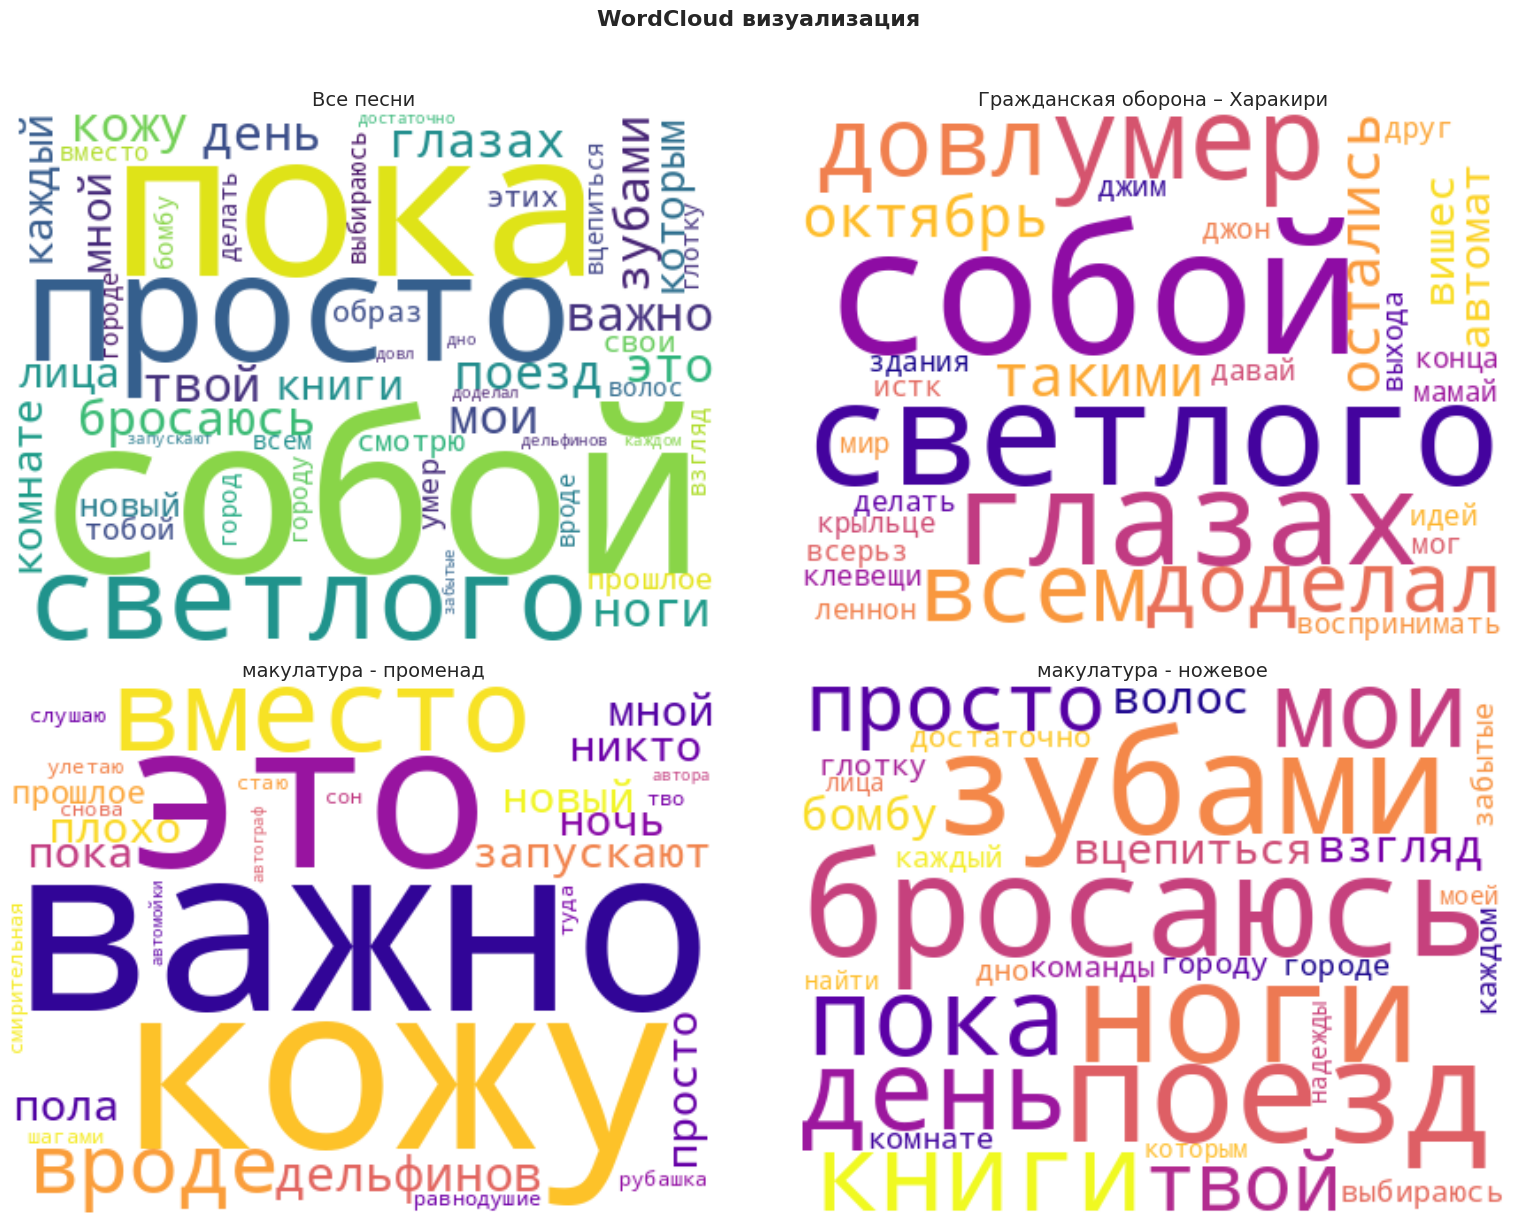

In [137]:
plot_wordclouds(count_vectorizer_matrix, feature_names, song_names)


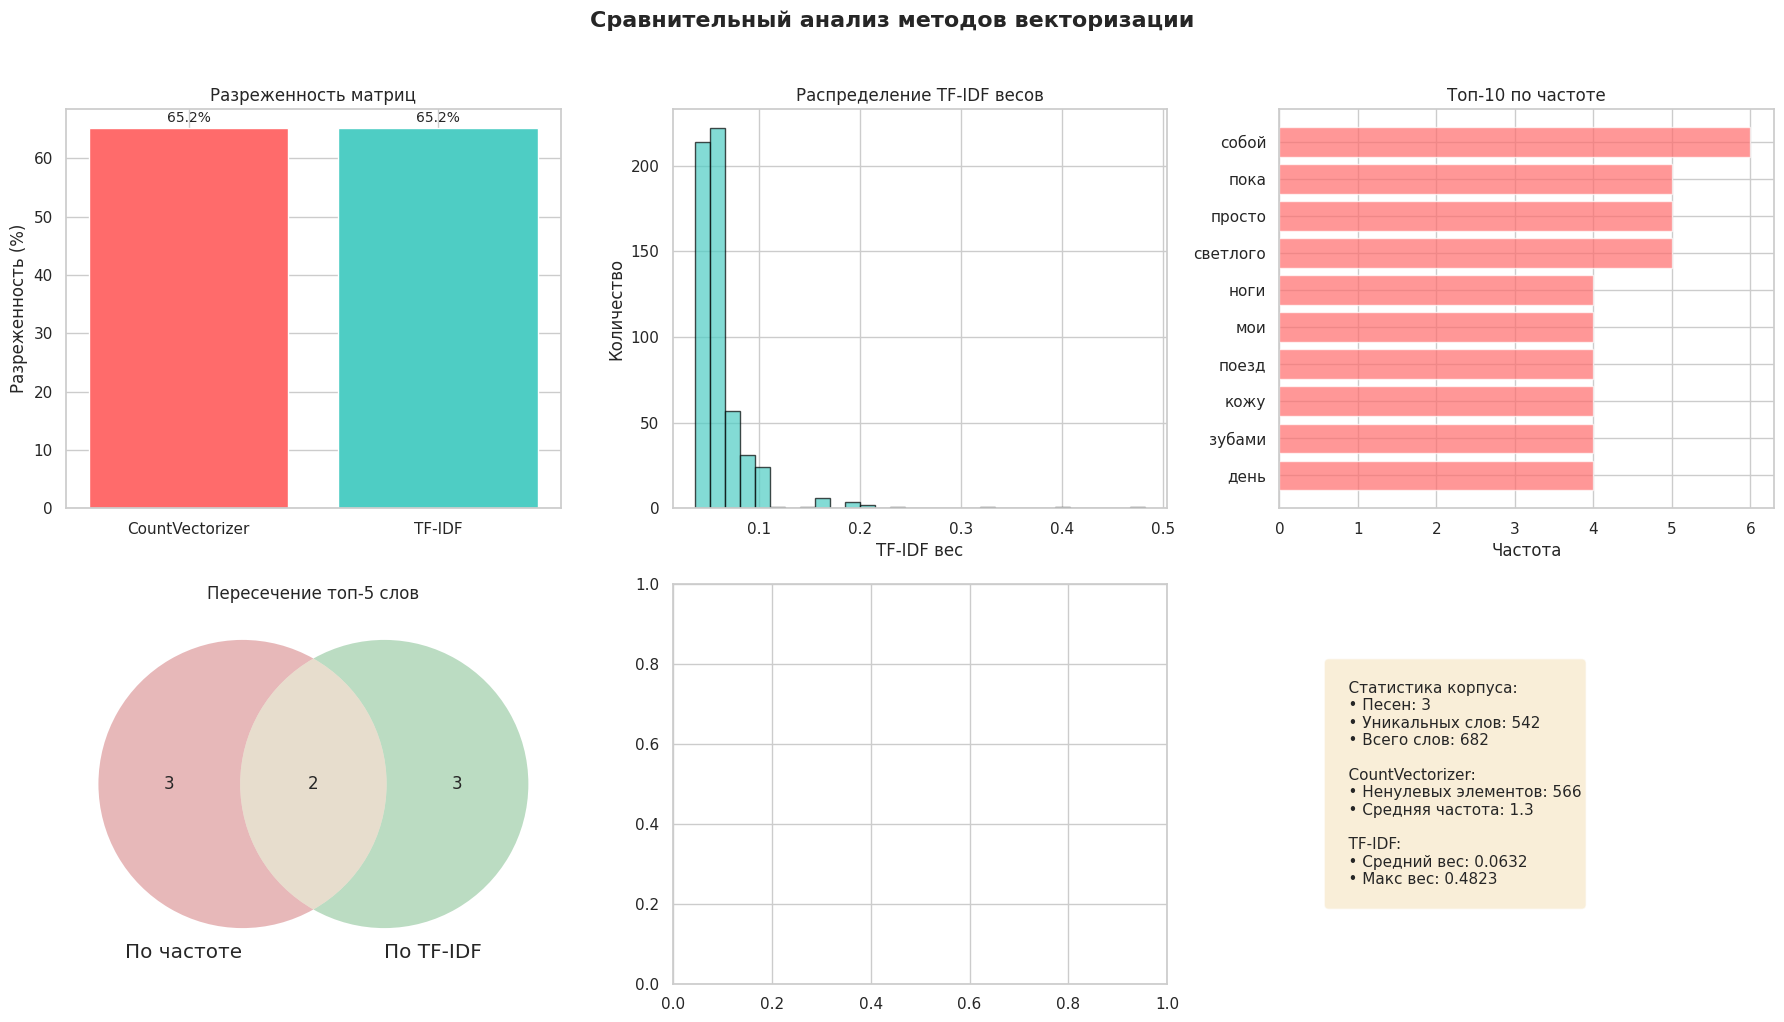

In [138]:
plot_methods_comparison(count_vectorizer_matrix, tf_idf_matrix,
                        feature_names, song_names)
